# Mandatory Assignment 2

This is the last of three mandatory assignments which must be completed during the course. Note that you only need to pass 2 out of 3 assignments to be eligible for the exam.

First some practical pieces of information:

* When is the assignment due?: **23:59, Friday, August 16, 2024.**
* Should I work with my group?: **Yes**. You should **hand in 1 assignment per member in the group** (this can be the same notebook for all group members or different notebooks, depending on your preferences)

The assignment consists of problems from the exercise sets that you have solved so far, problems from the exercises that have been modified a little to better suit the structure of the assignment and finally also new problems not seen in the exercises. 


### **<font color="red">STOP! Important information about grading!**

- It is important that you submit your edited version of this [notebook](https://fileinfo.com/extension/ipynb#:~:text=An%20IPYNB%20file%20is%20a,Python%20language%20and%20their%20data.) as a **single .ipynb file**, and nothing else. Do not copy your answers into another notebook that you have made as this won't fit the `nbgrader` format.
- **Don't delete, modify, or copy, the empty non-editable (unless you specifically change the metadata) cells below each question. Those are hidden tests used by the `nbgrader` software to grade the assignment (especially important if you use VSCode as the (hidden tests) cells are blank, but editable).**
- **Make sure to use the exact object names as referenced in the assignment. Consistency in object names ensures that `nbgrader` grades your assignment properly**
- It is recommended to clone our [github repository](https://github.com/isdsucph/isds2024) and copy the entire `assignment2` folder to somewhere on your computer and complete the assignment in this folder.
- It is good practice to always restart your notebook and run all cells before submitting or delivering your notebook to somebody else. This is to make sure that all cells run without raising any errors breaking the flow of the notebook (If the notebook can't run from start to end without errors, it can result in a "snowball-effect", making your grade lower).
- **Do not use absolute filepaths**. If you do this, your code will crash on other machines and we cannot grade the notebook. Use relative paths (e.g. `data/my_data.csv`) to load data or store results!

## Group 7:
- Oliver Nyrop Weeks (vsn684)
- Sofus Galavits Møller (qvc730)
- Victor V. Kristensen (gcp458)
- Jonas T. Schmidt (mcp656)

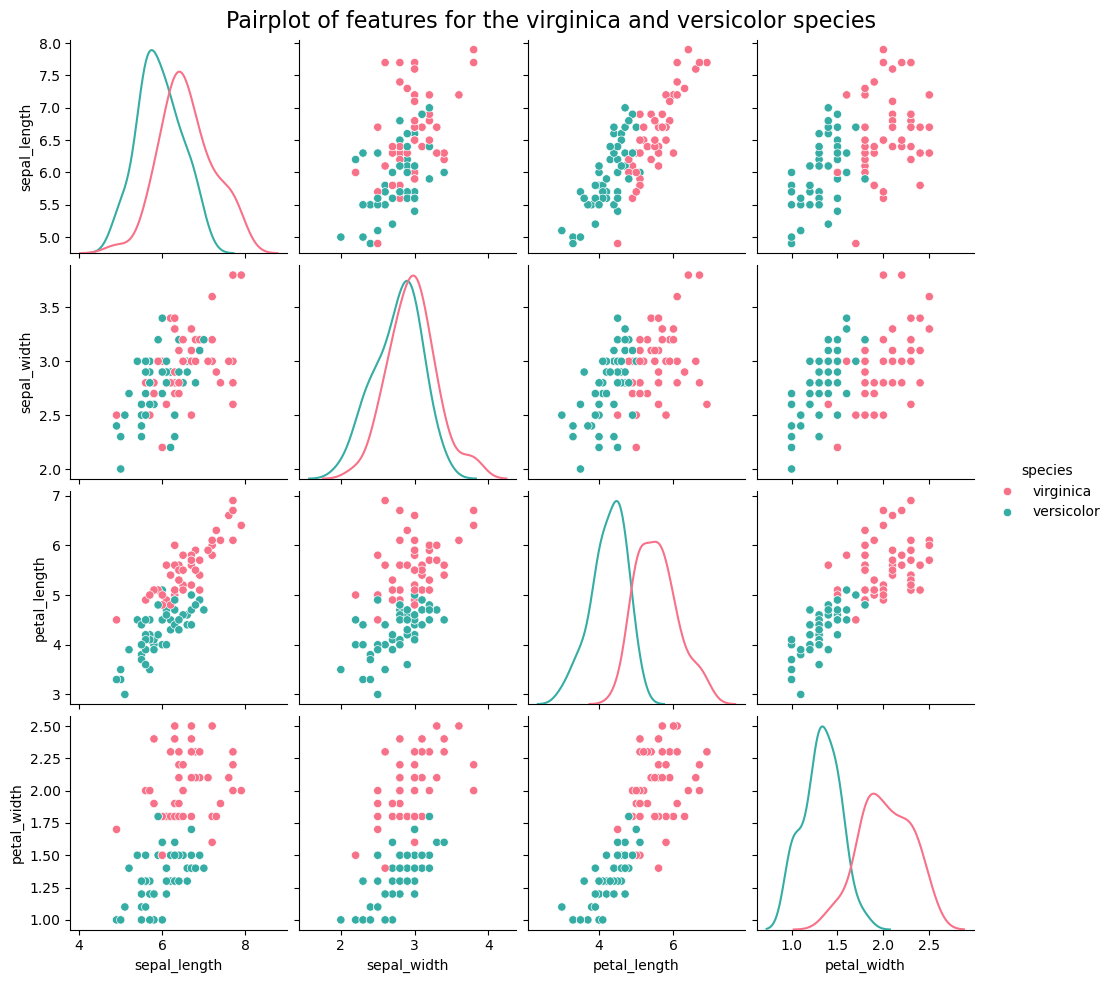

In [1]:
##############################################################
# RUN THIS CELL AND USE THE DATA TO SOLVE THE NEXT EXERCISES #
##############################################################

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

iris = sns.load_dataset('iris')
iris = (
    iris.query("species == 'virginica' | species == 'versicolor'")
    .sample(frac = 1, random_state = 3)
)
X = np.array(iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])
y = np.array(iris['species'].map({'virginica': 1, 'versicolor': -1}))

# EDA before modelling:
# Do the two species look perfectly linear seperable in any of the plots?
# (If they are not linear seperable the consequence is that the Perceptron algorithm
# won't converge, see Raschka's PML book)
ax = sns.pairplot(iris, hue="species", palette="husl", diag_kws = {'fill': False})
ax.fig.subplots_adjust(top=0.95)
ax.fig.suptitle('Pairplot of features for the virginica and versicolor species', fontsize=16)
plt.show()

# A very simple deterministic test-train split 
Xtrain = X[:70]
ytrain = y[:70]

Xtest = X[70:]
ytest = y[70:]

## Problems from Exercise Set 10:

> **Ex. 10.1.5:** Write a function named `perceptronEpoch` whichs loops over the training data (both X and y) using `zip`. For each row in the data, update the weights according to the perceptron rule (remember to update the bias in `w[0]`!). Set $\eta = 0.1$.
>
> Make sure the loop stores the total number of prediction errors encountered underways in the loop by creating an `int` which is incremented whenever you update the weights. 
>
> You can complete the function with the docstring below if you like or just delete it and paste in your own.
>> _Hint:_ your function should return the updated weights, as well as the number of errors made by the perceptron.
>
>> _Hint:_ The following code block implements the function in _pseudo_code (it wont run, but serves to communicate the functionality).
>> ```
>> function perceptronEpoch(X, y, W, eta):
>>    set errors = 0
>>
>>    for each pair xi, yi in zip(X,y) do:
>>        set update = eta * (yi - predict(xi, W))
>>        set W[1:] = W[1:] + update * xi
>>        set W[0] = W[0] + update
>>        set errors = errors + int(update != 0) 
>>
>>    return W, errors
>> ```
>
> *Bonus:* If you completed the previous bonus exercise (for 10.1.4), calculate the accuracy on training data using the updated weights as input in the predict function. Any progress yet?


You can use the following functions:

```python
def random_weights(location=0.0, scale=0.01, seed=1):
    # Init random number generator
    rgen = np.random.RandomState(seed)
    w = rgen.normal(loc=location, scale=scale, size=1 + X.shape[1])
    
    return w

def net_input(X, W): 
    return np.dot(X, W[1:]) + W[0]   # Linear product X'W + bias


def predict(X, W):
    linProd = net_input(X, W)
    return np.where(linProd >= 0.0, 1, -1)    # 1(linProd > 0)
```

>
> Make sure your function is named `perceptronEpoch` and takes the arguments `X, y, W, eta` (in the specified order)

In [2]:
def random_weights(location=0.0, scale=0.01, seed=1):
    # Init random number generator
    rgen = np.random.RandomState(seed)
    w = rgen.normal(loc=location, scale=scale, size=1 + X.shape[1])
    return w

def net_input(X, W): 
    return np.dot(X, W[1:]) + W[0]   # Linear product X'W + bias

def predict(X, W):
    linProd = net_input(X, W)
    return np.where(linProd >= 0.0, 1, -1)    # 1(linProd > 0)

def perceptronEpoch(X, y, W, eta=0.1):
    """Computes an epoch of training for the Perceptron algorithm.
    
    Args:
        X (np.ndarray): 
            Feature data of dimension (N, k) where k is the number 
            of features.
        y (np.ndarray):
            Target vector of dimension (N, ).
        W (np.ndarray):
            Weight vector of dimension (k + 1, ) where the first
            parameter is the bias term.
        eta (float): Learning rate of the algorithm, defaults to 0.1.
    
    Returns:
        tuple[np.ndarray, int]: 
            Updated weight vector and number of errors made 
            for the epoch of training.
    """
    
    errors = 0
    for xi, yi in zip(X, y):
        update = eta * (yi - predict(xi, W))
        W[1:] += update * xi
        W[0] += update
        errors += int(update != 0) 
    return W, errors

# Initialize weights
w = random_weights(location=0.0, scale=0.01, seed=1)

# Run the perceptron epoch on the training data
w, errors = perceptronEpoch(Xtrain, ytrain, w, eta=0.1)

# Output the number of errors and total samples
total_samples = len(ytrain)
print(f"Number of errors after one epoch: {errors} out of {total_samples} samples")

# Predict on the training set using the updated weights
predictions = predict(Xtrain, w)

# Calculate accuracy
accuracy = np.mean(predictions == ytrain)
print(f"Accuracy on the training set after one epoch: {accuracy:.2%}")

Number of errors after one epoch: 33 out of 70 samples
Accuracy on the training set after one epoch: 45.71%


> **Ex. 10.1.6:** Write a function named `Perceptron` which repeat the updating procedure (calls the function) you constructed in 10.1.5 for `n_iter` times by packing the whole thing in a loop. Make sure you store the number of errors in each iteration in a list. 
>
> Plot the total errors after each iteration in a graph with the number of epochs along the x-axis and errors along the y-axis.
>
>> _Hint:_ Make sure you dont reset the weights after each iteration.
>
>> _Hint:_ Once again some pseudocode:
>> ```
>> function Perceptron(X, y, n_iter):
>>     set eta = 0.1
>>     set weights = random_weights()
>>     set errorseq = list()
>>
>>     for each _ in range(n_iter):
>>         weights, e = f(X, y, W, eta) 
>>         errorseq.append(e)
>>
>>     return weights, errorseq
>> ```

Please make sure that your function is named `Perceptron` and takes the arguments `X, y, n_iter, eta`


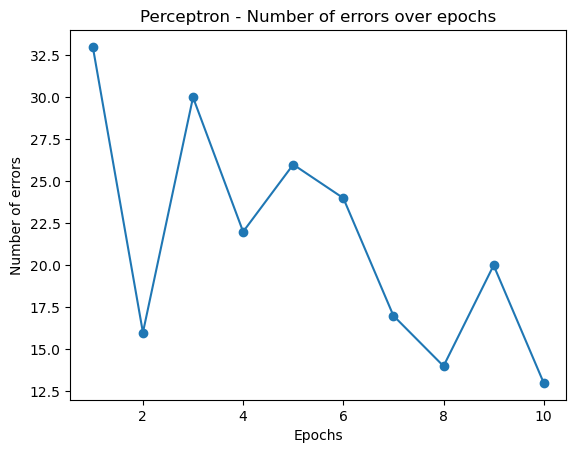

In [3]:
import matplotlib.pyplot as plt

def Perceptron(X, y, n_iter, eta=0.1):
    """Train the Perceptron algorithm over multiple epochs.
    """
    # Initialize weights
    W = random_weights(location=0.0, scale=0.01, seed=1)
    
    # List to store the number of errors after each epoch
    errors_seq = []
    
    # Iterate over the number of epochs
    for _ in range(n_iter):
        W, errors = perceptronEpoch(X, y, W, eta)
        errors_seq.append(errors)
    
    return W, errors_seq

# Running the Perceptron function for a specified number of epochs
n_iter = 10  # Number of epochs
w, errors_seq = Perceptron(Xtrain, ytrain, n_iter, eta=0.1)

# Plotting the number of errors over epochs
plt.plot(range(1, n_iter + 1), errors_seq, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of errors')
plt.title('Perceptron - Number of errors over epochs')
plt.show()


## Problems from Exercise Set 11:

### First part of Exercise Set 11: Implementing and evaluating the gradient decent for linear regression

In [4]:
##############################################################
# RUN THIS CELL AND USE THE DATA TO SOLVE THE NEXT EXERCISES #
##############################################################

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.exceptions import DataConversionWarning; import warnings
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

# Load the example tips dataset
tips = sns.load_dataset("tips")
tips_num = pd.get_dummies(tips, drop_first=True)  # Get dummies 

# Define feature matrix X and target vector y 
X = tips_num.drop('tip', axis = 1)
y = tips_num['tip']


## NOTE: It is important that the random_state parameter is set equal to 1
# to ensure that the same sequence of random numbers are generated as in
# the solution notebook.

# Split data into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=.5,
    random_state=1
)

# Standardize data - note that we only fit the standard scaler
# on X_train and use it on X_train, X_test.
norm_scaler = StandardScaler().fit(X_train) 
X_train = norm_scaler.transform(X_train) 
X_test = norm_scaler.transform(X_test) 

> **Ex. 11.1.5**: Make a function to update the weights given input target `y`, input features `X` and input weights `w` as well as learning rate, $\eta$, i.e. greek `eta`. Name the function `update_weight`. You should use matrix multiplication.


You can use the following functions inside `update_weight`:

```python
def net_input(X, w):    
    ''' Computes the matrix product between X and w. Note that
    X is assumed not to contain a bias/intercept column.'''
    # We have to add w_[0] separately because this is the constant term.
    # We could also have added a constant term to the X matrix to avoid
    # splitting the dot product up as below.
    return np.dot(X, w[1:]) + w[0]   
                                        

def compute_error(y, X, w):
    return y - net_input(X, w)
    
```

>
> Make sure your function takes the arguments `X, y, W, eta`.

In [5]:
def net_input(X, w):  
    """Calculate the net input (z) as the linear combination of features and weights."""  
    return np.dot(X, w[1:]) + w[0]   
                                        
def compute_error(y, X, w):
    """Compute the prediction errors."""
    return y - net_input(X, w)

def update_weight(X, y, w, eta):
    """Update the weights for linear regression using gradient descent."""
    # Compute the error (residuals)
    error = compute_error(y, X, w)
    
    # Update bias term separately
    w[0] += eta * error.sum()

    # Update weights for the features (not including bias)
    w[1:] += eta * np.dot(X.T, error)
    
    return w

> **Ex. 11.1.6**: Use the code below to initialize the weights in the variable `w` at zero given feature set `X`. Notice how we include an extra weight that includes the bias term. Set the learning rate `eta` to 0.001. Make a loop with 50 iterations where you iteratively apply your weight updating function. 

>```python
w = np.zeros(1 + X.shape[1])
```

In [6]:
# Initialize weights
w = np.zeros(1 + X_train.shape[1])

# Set the learning rate
eta = 0.001

# Number of iterations
n_iterations = 50

# Loop over the number of iterations
for i in range(n_iterations):
    w = update_weight(X_train, y_train, w, eta)

# After the loop, w contains the final weights after 50 iterations
print("Final weights after 50 iterations:", w)

Final weights after 50 iterations: [ 2.93273928  0.88898216  0.09724613  0.06636855  0.07694659  0.04776977
  0.00428532 -0.04183798 -0.01931789]


In [7]:
## This is a test cell, please don't delete it! 
## If it doesn't raise an error, your code works!
assert round(np.sum(w)) == 4
assert any(np.round(w, 2) == [ 2.93,  0.89,  0.1 ,  0.07,  0.08,  0.05,  0.  , -0.04, -0.02])

### Third part of Exercise Set 11: Modelling houseprices
In this example we will try to predict houseprices using a lot of variable (or features as they are called in Machine Learning). We are going to work with Kaggle's dataset on house prices, see information [here](https://www.kaggle.com/c/house-prices-advanced-regression-techniques), which also is to be found in `sklearn.datasets`. Kaggle is an organization that hosts competitions in building predictive models.

In [8]:
############################################################
#RUN THIS CELL AND USE THE DATA TO SOLVE THE NEXT EXERCISES#
############################################################

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

cal_house = fetch_california_housing()
X = pd.DataFrame(data=cal_house["data"], columns=cal_house["feature_names"]).iloc[
    :, :-2
]
y = cal_house["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1
)  # note random_state=1


> **Ex.11.3.1**: Generate interactions between all features to third degree, make sure you **exclude** the bias/intercept term. How many variables are there? Will OLS fail? Write 2 sentences. 
>
> After making interactions rescale the features to have zero mean, unit std. deviation. Should you use the distribution of the training data to rescale the test data?  Write 1 sentence. 
>
>> *Hint 1*: Try importing `PolynomialFeatures` from `sklearn.preprocessing`
>
>> *Hint 2*: If in doubt about which distribution to scale, you may read [this post](https://stats.stackexchange.com/questions/174823/how-to-apply-standardization-normalization-to-train-and-testset-if-prediction-i).

Name you transformed training data set `X_train2` and your test data set `X_test2`

In [9]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Generate interactions between all features to the third degree
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 2. Count the number of variables
n_variables = X_train_poly.shape[1]
print(f'Number of variables after polynomial transformation: {n_variables}')

# 3. Check if OLS will fail:
# Attempt to fit a linear regression model and observe if it succeeds
try:
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train)
    print("OLS did not fail with the polynomial features.")
except Exception as e:
    print(f"OLS failed with the polynomial features: {e}")

# 4. Rescale the features to have zero mean and unit std. deviation
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test data
X_train2 = scaler.fit_transform(X_train_poly)
X_test2 = scaler.transform(X_test_poly)

print("\nFeatures have been rescaled to have zero mean and unit standard deviation.\n")

# Check the mean and standard deviation of the scaled features
mean_scaled_train = np.mean(X_train2)
std_scaled_train = np.std(X_train2)

mean_scaled_test = np.mean(X_test2)
std_scaled_test = np.std(X_test2)

print(f'Mean of scaled training data: {mean_scaled_train}')
print(f'Std deviation of scaled training data: {std_scaled_train}')

print(f'Mean of scaled test data: {mean_scaled_test}')
print(f'Std deviation of scaled test data: {std_scaled_test}')

# OLS does not fail because the number of variables (83) does not exceed the observations.
# Yes, use the training data's distribution to scale the test data.
# We must not fit on the test data; scaling ensures consistency across training and test sets.

Number of variables after polynomial transformation: 83
OLS did not fail with the polynomial features.

Features have been rescaled to have zero mean and unit standard deviation.

Mean of scaled training data: -7.538774146105107e-17
Std deviation of scaled training data: 1.0000000000000007
Mean of scaled test data: 0.00668400795196582
Std deviation of scaled test data: 2.1487150358539577


> **Ex.11.3.2**: Construct a list of 20 $\lambda$ values in the range from $10^{-4}$ to $10^4$ to be used in the Lasso model. For each $\lambda$ estimate the Lasso model on the rescaled train data, calculate the _Root Mean_ Squared Error (RMSE) for the rescaled train data, `X_train2`, and the _Root Mean_ Squared Error (RMSE) for the rescaled test data, `X_test2`. For each iteration store the given $\lambda$ and the calculated RMSEs for the rescaled train and test data in a list named `output`. 

> *Hint*: use `np.logspace(-4, 4, 20)` to create the list of lambdas to loop. 

> *Hint*: You can use the following code from scikit-learn to compute the _mean_ squared error.
```python
from sklearn.metrics import mean_squared_error as mse
mse(y_true, y_pred)
```

In [10]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error as mse
import numpy as np

# Create a list of 20 lambda values from 10^-4 to 10^4
lambdas = np.logspace(-4, 4, 20)

# List to store the output (lambda, RMSE_train, RMSE_test)
output = []

for alpha in lambdas:
    lasso = Lasso(alpha=alpha, max_iter=10000)  # Use a large max_iter to ensure convergence
    lasso.fit(X_train2, y_train)
    
    # Predict on train and test data
    y_train_pred = lasso.predict(X_train2)
    y_test_pred = lasso.predict(X_test2)
    
    # Calculate RMSE for train and test data
    rmse_train = np.sqrt(mse(y_train, y_train_pred))
    rmse_test = np.sqrt(mse(y_test, y_test_pred))
    
    # Store the lambda and RMSE values
    output.append((alpha, rmse_train, rmse_test))

# Output now contains tuples of (lambda, RMSE_train, RMSE_test)


/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.332e+03, tolerance: 1.365e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.232e+02, tolerance: 1.365e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

In [11]:
## This is a test cell, please don't delete it! 
## If it doesn't raise an error when run your code works!
assert any(np.sort(np.round(np.mean(output, axis=0))) == [1.0, 2.0, 806.0])

> **Ex.11.3.3**: Make a plot with the lambdas on the x-axis and the RMSE measures on the y-axis. What happens to RMSE for train and test data as $\lambda$ increases? The x-axis should be log scaled. Which one are we interested in minimizing? 

> Bonus: Can you find the lambda that gives the lowest MSE-test score?

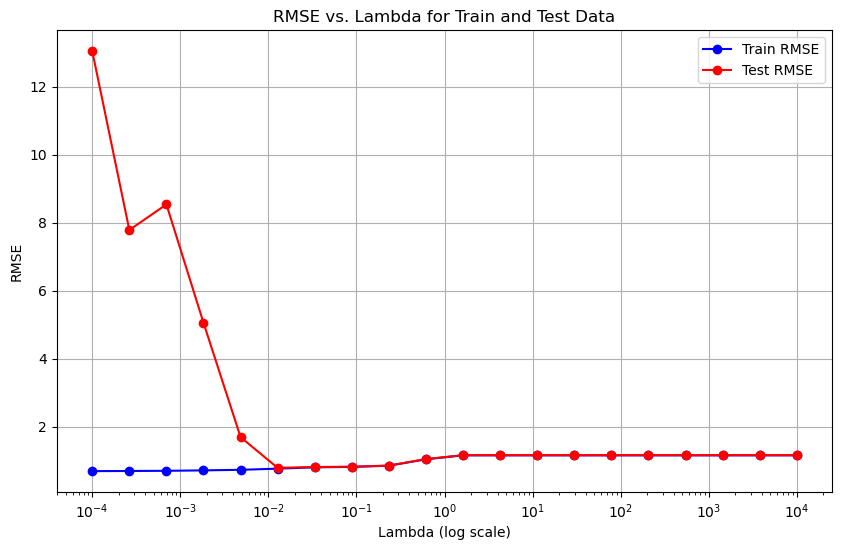

The best lambda is 0.0127 with a Test RMSE of 0.7830


In [12]:
import matplotlib.pyplot as plt

# Extract lambdas, train RMSEs, and test RMSEs from the output list
lambdas = [item[0] for item in output]
train_rmse = [item[1] for item in output]
test_rmse = [item[2] for item in output]

# Plot the RMSE values against the lambdas
plt.figure(figsize=(10, 6))
plt.plot(lambdas, train_rmse, label='Train RMSE', marker='o', linestyle='-', color='b')
plt.plot(lambdas, test_rmse, label='Test RMSE', marker='o', linestyle='-', color='r')
plt.xscale('log')  # Log scale for the x-axis
plt.xlabel('Lambda (log scale)')
plt.ylabel('RMSE')
plt.title('RMSE vs. Lambda for Train and Test Data')
plt.legend()
plt.grid(True)
plt.show()

# Find the lambda that gives the lowest RMSE on the test data
min_rmse = min(test_rmse)
best_lambda = lambdas[test_rmse.index(min_rmse)]

print(f"The best lambda is {best_lambda:.4f} with a Test RMSE of {min_rmse:.4f}")


## Problems from Exercise Set 12:

> **Ex. 12.2.3:**
Run a Lasso regression using the Pipeline from `Ex 12.2.2` which is given in the code cell below. In the outer loop searching through the 12 lambda values as specified below. 
In the inner loop make *5 fold cross validation* on the selected model and store the average MSE for each fold. Which lambda, from the selection below, gives the lowest test MSE?
 ```python 
lambdas =  np.logspace(-4, 4, 12)
```
 *Hint:* `KFold` in `sklearn.model_selection` may be useful.

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Lasso

# Pipeline from Ex. 12.2.2
pipe_lasso = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    Lasso(random_state=1),
)

# The feature matrix X and target vector y are defined
# in the code cell "Second part of Exercise Set 11: Modelling houseprices".

# Split X, y into development (2/3) and test data (1/3).
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=(1 / 3), random_state=1)

lambdas = np.logspace(-4, 4, 12)

# YOUR CODE HERE
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd

# Initialize KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# To store the results
results = []

# Outer loop through each lambda
for lmbda in lambdas:
    # Update the Lasso model in the pipeline with the current lambda
    pipe_lasso.set_params(lasso__alpha=lmbda)
    
    # Perform 5-fold cross-validation and compute the MSE for each fold
    mse_scores = -cross_val_score(pipe_lasso, X_dev, y_dev, cv=kf, scoring='neg_mean_squared_error')
    
    # Store the average MSE for this lambda
    avg_mse = mse_scores.mean()
    results.append((lmbda, avg_mse))

# Convert results to a DataFrame for easy analysis
results_df = pd.DataFrame(results, columns=["Lambda", "Average MSE"])

# Find the lambda with the lowest average MSE
best_lambda = results_df.loc[results_df['Average MSE'].idxmin()]

# Display the results
print("Lambda and Average MSE for each fold:")
print(results_df)

print("\nBest Lambda:")
print(best_lambda)

/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.307e+03, tolerance: 1.477e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.253e+03, tolerance: 1.474e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

Lambda and Average MSE for each fold:
          Lambda  Average MSE
0       0.000100    48.029431
1       0.000534    32.510491
2       0.002848     9.375870
3       0.015199     0.637857
4       0.081113     0.666612
5       0.432876     0.884477
6       2.310130     1.342765
7      12.328467     1.342765
8      65.793322     1.342765
9     351.119173     1.342765
10   1873.817423     1.342765
11  10000.000000     1.342765

Best Lambda:
Lambda         0.015199
Average MSE    0.637857
Name: 3, dtype: float64


## New problems in Assignment 2

> One of the fastest ways to extract and structure relevant information from text is by using regular expressions (regexes). In the following exercises we will leverage the power of regexes to extract relevant information from a text snippet of a meeting in the Danish parliament taken from [here](https://www.folketingstidende.dk/samling/20211/salen/M41/20211_M41_referat.pdf). 

> The text snippet is located in a txt file named `parliamentmeeting.txt` in the `data` folder inside this assignment repository. The snippet has been extracted from the pdf file using the `pdfreader` [package]([link](https://pdfreader.readthedocs.io/en/latest/)). The snippet consists of all text from page 2-4 (inclusive) of the original pdf file.
>
> Our goal is to extract all speakers with their corresponding speech from the text snippet. 
>
> **Ex. N.1**: Write a regex that matches 
> - The time that the speaker started to speak
> - A possible title in parenthesis
> - The name of the speaker
> - The political affiliation of the speaker
> - An ending colon
> 
>  from the strings in the list `TEST_STRINGS` defined below. The regex should be stored in a variable named `re_find_speakers`. 
> 
> 
> When applied to the strings in the list it should yield the output below:

```python
# Loop through each string and search for a match with the regex
for string in TEST_STRINGS:  
    print(re_find_speakers.search(string))
    
## Output:
# <re.Match object; span=(20, 68), match='Kl. 09:03(Ordfører)Christian Rabjerg Madsen (S):'>
# <re.Match object; span=(20, 63), match='Kl. 09:12Formanden (Henrik Dam Kristensen):'>
# <re.Match object; span=(20, 53), match='Kl. 09:12Troels Lund Poulsen (V):'>
# <re.Match object; span=(20, 63), match='Kl. 09:13Formanden (Henrik Dam Kristensen):'>
```
- *Hint 1:* To avoid drowning in regex expressions use the `re.VERBOSE` flag. This allows one to split a regex on multiple lines and write comments to each specific expression. See the Python regex tutorial [here](https://docs.python.org/3/howto/regex.html)
- *Hint 2:* [Capture groups and named capture groups](https://www.pythontutorial.net/python-regex/python-regex-capturing-group/) might be a help to organize your regex
- *Hint 3:* Consult [this](https://www.debuggex.com/cheatsheet/regex/python) cheatsheet for help

In [14]:
# Import the re module used to construct and use regexes in python
import re

In [15]:
import re

# Define the regex pattern
re_find_speakers = re.compile(r"""
    \bKl\.\s*\d{2}:\d{2}              # Time in format 'Kl. HH:MM', ensuring 'Kl.' is at a word boundary
    \s*                               # Optional whitespace
    (                                 # Start optional group for title and name
        \(?                           # Optional opening parenthesis for title
        (?P<title>[^\)]+)?            # Optional title, allowing any character except closing parenthesis
        \)?                           # Optional closing parenthesis for title
        \s*                           # Optional whitespace
    )?                                # End optional group for title
    (?P<name>[A-Za-zæøåÆØÅ\s\-]+)     # Name of the speaker
    \s*\((?P<party>[^)]+)\)           # Political affiliation in parentheses, allowing any character except closing parenthesis
    :                                 # Colon indicating end of speaker's info
    """, re.VERBOSE)

# Test strings to verify the regex pattern
TEST_STRINGS = [
    ", Socialdemokratiet.Kl. 09:03(Ordfører)Christian Rabjerg Madsen (S):Tak for det. For to ", 
    "det og glædelig jul.Kl. 09:12Formanden (Henrik Dam Kristensen):Ja, det varer lidt, ", 
    "nd Poulsen, Venstre.Kl. 09:12Troels Lund Poulsen (V):Tak for det. Tak for", 
    "r Socialdemokratiet?Kl. 09:13Formanden (Henrik Dam Kristensen):Ordføreren, værsgo.K", 
]

# Loop through each string and search for a match with the regex
for string in TEST_STRINGS:
    match = re_find_speakers.search(string)
    print(match)


<re.Match object; span=(20, 68), match='Kl. 09:03(Ordfører)Christian Rabjerg Madsen (S):'>
<re.Match object; span=(20, 63), match='Kl. 09:12Formanden (Henrik Dam Kristensen):'>
<re.Match object; span=(20, 53), match='Kl. 09:12Troels Lund Poulsen (V):'>
<re.Match object; span=(20, 63), match='Kl. 09:13Formanden (Henrik Dam Kristensen):'>


In [16]:
## This is a test cell, please don't delete it! 
## If it doesn't raise an error when run your code works!

# Get matches for each test string
matches = [re_find_speakers.search(string) for string in TEST_STRINGS]

# Matched spans
spans = [match.span() for match in matches]
assert spans == [(20, 68), (20, 63), (20, 53), (20, 63)]

# Matched strings
matched_strings = [match.group(0) for match in matches]
assert matched_strings == [
    'Kl. 09:03(Ordfører)Christian Rabjerg Madsen (S):',
    'Kl. 09:12Formanden (Henrik Dam Kristensen):',
    'Kl. 09:12Troels Lund Poulsen (V):',
    'Kl. 09:13Formanden (Henrik Dam Kristensen):'
]

> **Ex. N.2**: Load the `parliamentmeeting.txt` file from the `data` folder into a variable named `parliament_meeting`. Next, apply your regex `re_find_speakers` to the text snippet stored in `parliament_meeting` using the `finditer` method of the regex. Use a list comprehension to store each match in a list named `meeting`. You should write something like:

```python
matches = [match for match in re_find_speakers.finditer(parliament_meeting)]
```

In [28]:
with open('data/parliamentmeeting.txt', 'r', encoding='utf-8') as file:
    parliament_meeting = file.read()

meeting = [match for match in re_find_speakers.finditer(parliament_meeting)]

for match in meeting:
    print(match.group())

Kl. 09:03(Ordfører)Christian Rabjerg Madsen (S):
Kl. 09:12Formanden (Henrik Dam Kristensen):
Kl. 09:12Troels Lund Poulsen (V):
Kl. 09:13Formanden (Henrik Dam Kristensen):
Kl. 09:14Christian Rabjerg Madsen (S):
Kl. 09:15Formanden (Henrik Dam Kristensen):
Kl. 09:15Troels Lund Poulsen (V):
Kl. 09:16Formanden (Henrik Dam Kristensen):
Kl. 09:16Christian Rabjerg Madsen (S):
Kl. 09:16Formanden (Henrik Dam Kristensen):
Kl. 09:16René Christensen (DF):
Kl. 09:17Formanden (Henrik Dam Kristensen):
Kl. 09:17Christian Rabjerg Madsen (S):
Kl. 09:18Formanden (Henrik Dam Kristensen):
Kl. 09:19René Christensen (DF):
Kl. 09:19Formanden (Henrik Dam Kristensen):
Kl. 09:19Christian Rabjerg Madsen (S):
Kl. 09:20Formanden (Henrik Dam Kristensen):
Kl. 09:20Lisbeth Bech-Nielsen (SF):
Kl. 09:21Formanden (Henrik Dam Kristensen):
Kl. 09:21Christian Rabjerg Madsen (S):
Kl. 09:22Formanden (Henrik Dam Kristensen):


In [29]:
## This is a test cell, please don't delete it! 
## If it doesn't raise an error when run your code works!
matches = [match for match in re_find_speakers.finditer(parliament_meeting)]
spans = [match.span() for match in matches]
assert spans == [
    (61, 109),
    (8641, 8684),
    (8880, 8913),
    (9983, 10026),
    (10045, 10083),
    (11136, 11179),
    (11211, 11244),
    (12435, 12478),
    (12560, 12598),
    (13161, 13204),
    (13253, 13284),
    (14683, 14726),
    (14745, 14783),
    (16039, 16082),
    (16111, 16142),
    (16975, 17018),
    (17037, 17075),
    (17843, 17886),
    (17915, 17950),
    (18911, 18954),
    (18973, 19011),
    (20253, 20296),
]

names = [match.group() for match in matches]
assert names == [
    "Kl. 09:03(Ordfører)Christian Rabjerg Madsen (S):",
    "Kl. 09:12Formanden (Henrik Dam Kristensen):",
    "Kl. 09:12Troels Lund Poulsen (V):",
    "Kl. 09:13Formanden (Henrik Dam Kristensen):",
    "Kl. 09:14Christian Rabjerg Madsen (S):",
    "Kl. 09:15Formanden (Henrik Dam Kristensen):",
    "Kl. 09:15Troels Lund Poulsen (V):",
    "Kl. 09:16Formanden (Henrik Dam Kristensen):",
    "Kl. 09:16Christian Rabjerg Madsen (S):",
    "Kl. 09:16Formanden (Henrik Dam Kristensen):",
    "Kl. 09:16René Christensen (DF):",
    "Kl. 09:17Formanden (Henrik Dam Kristensen):",
    "Kl. 09:17Christian Rabjerg Madsen (S):",
    "Kl. 09:18Formanden (Henrik Dam Kristensen):",
    "Kl. 09:19René Christensen (DF):",
    "Kl. 09:19Formanden (Henrik Dam Kristensen):",
    "Kl. 09:19Christian Rabjerg Madsen (S):",
    "Kl. 09:20Formanden (Henrik Dam Kristensen):",
    "Kl. 09:20Lisbeth Bech-Nielsen (SF):",
    "Kl. 09:21Formanden (Henrik Dam Kristensen):",
    "Kl. 09:21Christian Rabjerg Madsen (S):",
    "Kl. 09:22Formanden (Henrik Dam Kristensen):",
]


> **Ex. N.3**: Use the matches in the list `matches` to extract the speech of each speaker. You can store the result in a data structure of your choice. For example, you could store each speaker and the corresponding speech as a list of tuples. Finally, print out each speaker and the corresponding speech. Ideally, you should get an output akin to the one in the screenshot shown in the cell below.

> - *Hint 1:* You can locate each speaker in the text snippet stored in `parliament_meeting` by writing `match.span()` on each match and subsetting `parliament_meeting` by the indices returned. I.e. the first match returns the tuple `(61, 109)` when computing `matches[0].span()`. This means that the place in the original text where our regex found a match can be found from index `61` to `109` of the text snippet. See the code snippet below
```python
start_idx, end_idx = matches[0].span()  # (61, 109)
print(parliament_meeting[start_idx:end_idx])
## Output
# Kl. 09:03(Ordfører)Christian Rabjerg Madsen (S):
```
> - *Hint 2:* To find the first speaker's speech locate the next speaker in the text and extract all text starting from the first speaker until the next speaker. Repeat this for all pairs.

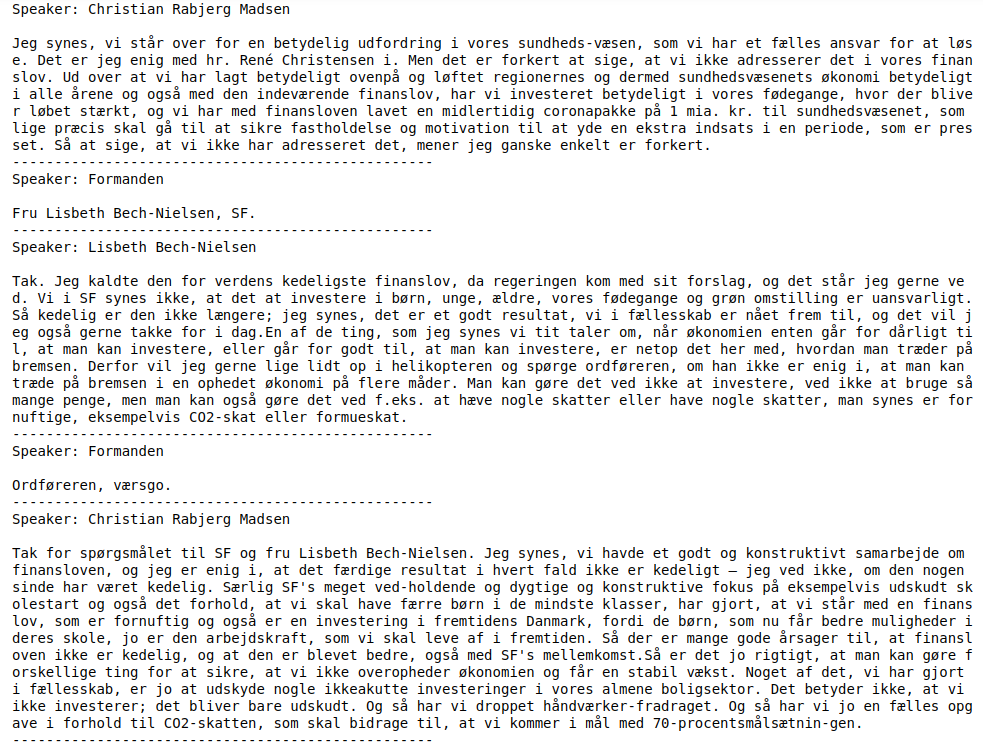

In [30]:
# Display example of printout
from IPython.display import Image
Image("parliament-meeting-printout.png", width=800)

In [47]:
import re

# Create a list to store the results
speeches = []

# Iterate through the matches to extract each speaker's speech
for i, match in enumerate(meeting):
    start_idx, end_idx = match.span()
    
    # Extract the speaker's full information
    speaker_info = parliament_meeting[start_idx:end_idx]

    # Remove time and anything in parentheses using regex
    speaker_name = re.sub(r'Kl\.\s*\d{2}:\d{2}', '', speaker_info)  # Remove the time part
    speaker_name = re.sub(r'\(.*?\)', '', speaker_name)  # Remove anything in parentheses
    speaker_name = re.sub(r':\s*$', '', speaker_name)  # Remove trailing colon and spaces
    speaker_name = speaker_name.strip()  # Remove any extra whitespace
    
    # Determine the start of the speech
    speech_start = end_idx
    
    # Determine the end of the speech
    if i + 1 < len(meeting):
        speech_end = meeting[i + 1].span()[0]  # Start of the next speaker
    else:
        speech_end = len(parliament_meeting)  # End of the text for the last speaker
    
    # Extract the speech
    speech_text = parliament_meeting[speech_start:speech_end].strip()
    
    # Store the speaker name and speech in the list
    speeches.append((speaker_name, speech_text))

# Print out each speaker and their corresponding speech
for speaker_name, speech_text in speeches:
    print(f"{speaker_name}:\n")
    print(f"{speech_text}")
    print("-" * 50)  # Separator for clarity


Christian Rabjerg Madsen:

Tak for det. For to et halvt år siden satte danskerne en ny kurs. Valget i 2019 var et klimavalg. De unge gik forrest og krævede grøn handling. Det budskab blev hørt. Den socialdemokratiske regering blev dannet på verdens formentlig mest ambitiøse og grønne klima-vision: 70 pct. CO2-reduktion i 2030. Nu efter to et halvt års inten-sivt arbejde, forhandlinger og armlægninger har vi 8 år før deadline med over 50 aftaler med hinanden bragt os mere end halvvejs til det mål. Jeg vil gerne sige tak til de partier, der har løftet den opgave sammen med regeringen.Med tempoet og ambitionerne i den grønne omstilling har vi bevæget os væk fra Venstres grønne realisme, et begreb, der i sidste regeringsperiode helt konkret dækkede over, at Venstreregeringen aflyste grønne målsætninger, og som dækkede over reelle sorte tilba-geskridt i forhold til eksempelvis udfasning af kul og drivhusgasre-duktioner. Vi har bevæget os væk fra en situation, hvor den tidligere Venstrereger